In [1]:
import sys
sys.path.append("..")  # jotta src/features.py löytyy notebookista

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.features import add_group_a_features

# Lataa setupit
setups = pd.read_parquet("../data/processed/setups.parquet")
print(f"Ladattu {len(setups)} setupia")

Ladattu 8281 setupia


In [2]:
# Lisää Ryhmä A:n piirteet
df = add_group_a_features(setups)

# Katsotaan uudet sarakkeet
new_cols = ["box_size_pct", "entry_position_in_box", "entry_outside_box", "hour_sin", "hour_cos"]
print("Uudet sarakkeet:")
df[new_cols].describe()

Uudet sarakkeet:


KeyError: "['box_size_pct'] not in index"

In [ ]:
print("NaN-arvot uusissa sarakkeissa:")
print(df[new_cols].isna().sum())

NaN-arvot uusissa sarakkeissa:
box_size_pct             0
entry_position_in_box    0
entry_outside_box        0
hour_sin                 0
hour_cos                 0
dtype: int64


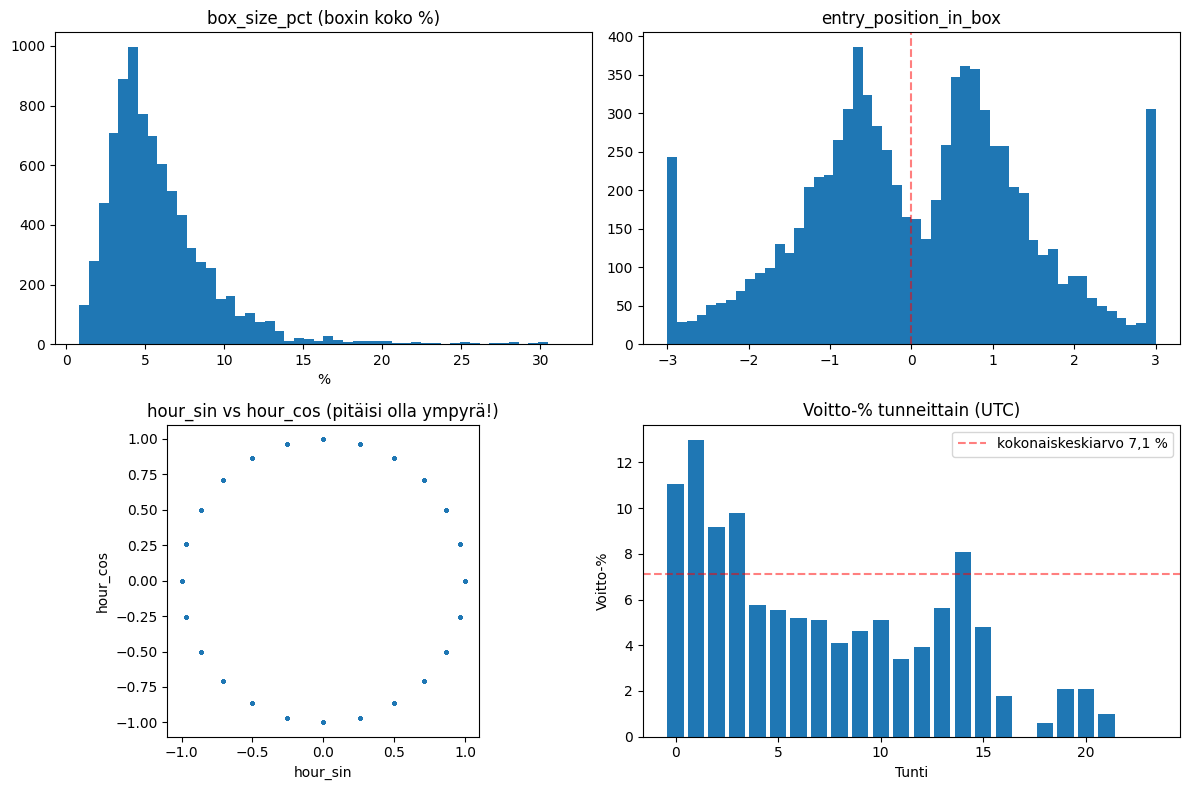

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["box_size_pct"].dropna(), bins=50)
axes[0, 0].set_title("box_size_pct (boxin koko %)")
axes[0, 0].set_xlabel("%")

axes[0, 1].hist(df["entry_position_in_box"].dropna(), bins=50)
axes[0, 1].set_title("entry_position_in_box")
axes[0, 1].axvline(0, color="red", linestyle="--", alpha=0.5)

axes[1, 0].scatter(df["hour_sin"], df["hour_cos"], alpha=0.05, s=5)
axes[1, 0].set_title("hour_sin vs hour_cos (pitäisi olla ympyrä!)")
axes[1, 0].set_xlabel("hour_sin")
axes[1, 0].set_ylabel("hour_cos")
axes[1, 0].set_aspect("equal")

# Tunti vs voitto-% (vain labeled setupit)
labeled = df.dropna(subset=["label"]).copy()
labeled["hour"] = labeled["entry_time"].dt.hour
hourly_winrate = labeled.groupby("hour")["label"].agg(["mean", "count"])
axes[1, 1].bar(hourly_winrate.index, hourly_winrate["mean"] * 100)
axes[1, 1].set_title("Voitto-% tunneittain (UTC)")
axes[1, 1].set_xlabel("Tunti")
axes[1, 1].set_ylabel("Voitto-%")
axes[1, 1].axhline(7.1, color="red", linestyle="--", alpha=0.5, label="kokonaiskeskiarvo 7,1 %")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Kuinka monta "epätavallista" entry_position_in_box -arvoa on?
extreme = df["entry_position_in_box"].abs() > 2
print(f"Setupeja joissa |entry_position_in_box| > 2: {extreme.sum()} ({extreme.mean()*100:.1f} %)")

extreme5 = df["entry_position_in_box"].abs() > 5
print(f"Setupeja joissa |entry_position_in_box| > 5: {extreme5.sum()} ({extreme5.mean()*100:.1f} %)")

# Katsotaan muutama ääriesimerkki
print("\nÄäripäät:")
print(df.nlargest(3, "entry_position_in_box")[["symbol", "date", "direction", "box_high", "box_low", "entry_price", "entry_position_in_box"]])
print()
print(df.nsmallest(3, "entry_position_in_box")[["symbol", "date", "direction", "box_high", "box_low", "entry_price", "entry_position_in_box"]])

Setupeja joissa |entry_position_in_box| > 2: 1252 (15.1 %)
Setupeja joissa |entry_position_in_box| > 5: 0 (0.0 %)

Ääripäät:
     symbol                      date direction  box_high  box_low  \
21  ETHUSDT 2024-01-08 00:00:00+00:00     short   2258.01  2203.46   
22  ETHUSDT 2024-01-08 00:00:00+00:00     short   2258.01  2203.46   
31  ETHUSDT 2024-01-10 00:00:00+00:00     short   2371.72  2226.78   

    entry_price  entry_position_in_box  
21      2328.72                    3.0  
22      2352.96                    3.0  
31      2534.64                    3.0  

    symbol                      date direction  box_high  box_low  \
3  ETHUSDT 2024-01-03 00:00:00+00:00      long    2431.3   2341.0   
4  ETHUSDT 2024-01-03 00:00:00+00:00      long    2431.3   2341.0   
5  ETHUSDT 2024-01-03 00:00:00+00:00      long    2431.3   2341.0   

   entry_price  entry_position_in_box  
3      2221.27                   -3.0  
4      2202.54                   -3.0  
5      2207.42                  

In [ ]:
# Kuinka usein boxi on rikki sisäänmenohetkellä?
print(f"entry_outside_box = 1: {df['entry_outside_box'].sum()} setupia ({df['entry_outside_box'].mean()*100:.1f} %)")

# Onko tällä piirteellä yksinään ennustearvoa?
labeled = df.dropna(subset=["label"])
print("\nVoitto-% lipun mukaan (vain labeled setupit):")
print(labeled.groupby("entry_outside_box")["label"].agg(["mean", "count"]))

entry_outside_box = 1: 3805 setupia (45.9 %)

Voitto-% lipun mukaan (vain labeled setupit):
                       mean  count
entry_outside_box                 
0                  0.098185   3911
1                  0.031136   2730


In [ ]:
# Yhdistetään säännöt: ensimmäinen setup per päivä JA boxi ehjä
combined = labeled[
    (labeled["setup_index_in_day"] == 1) &
    (labeled["entry_outside_box"] == 0)
]
print(f"Ensimmäinen setup + boxi ehjä: n={len(combined)}, voitto-% = {combined['label'].mean()*100:.1f} %")

# Verrokit:
first_only = labeled[labeled["setup_index_in_day"] == 1]
print(f"Vain ensimmäinen setup:        n={len(first_only)}, voitto-% = {first_only['label'].mean()*100:.1f} %")

inside_only = labeled[labeled["entry_outside_box"] == 0]
print(f"Vain boxi ehjä:                n={len(inside_only)}, voitto-% = {inside_only['label'].mean()*100:.1f} %")

# Ja vielä expected value (R/R huomioiden)
# Voitto = label * R/R, häviö = -1
combined_ev = (combined["label"] * combined["risk_reward_ratio"] - (1 - combined["label"])).mean()
print(f"\nYhdistetyn säännön Expected Value per kauppa (R-yksiköissä): {combined_ev:.3f}")

Ensimmäinen setup + boxi ehjä: n=1508, voitto-% = 11.3 %
Vain ensimmäinen setup:        n=1610, voitto-% = 11.0 %
Vain boxi ehjä:                n=3911, voitto-% = 9.8 %

Yhdistetyn säännön Expected Value per kauppa (R-yksiköissä): -0.293


In [ ]:
# Mitkä ovat R/R-tunnusluvut tässä alaryhmässä?
print("Yhdistetty sääntö (n=1508):")
print(f"  R/R mediaani: {combined['risk_reward_ratio'].median():.2f}")
print(f"  R/R keskiarvo: {combined['risk_reward_ratio'].mean():.2f}")
print(f"  Voitto-%:       {combined['label'].mean()*100:.1f} %")

# Erottele voittajat ja häviäjät
winners = combined[combined["label"] == 1]
losers = combined[combined["label"] == 0]
print(f"\n  Voittavien R/R mediaani: {winners['risk_reward_ratio'].median():.2f}")
print(f"  Häviävien R/R mediaani:  {losers['risk_reward_ratio'].median():.2f}")

# Vertailu: koko aineisto
print("\nKoko labeled aineisto:")
all_winners = labeled[labeled["label"] == 1]
all_losers = labeled[labeled["label"] == 0]
print(f"  Voittavien R/R mediaani: {all_winners['risk_reward_ratio'].median():.2f}")
print(f"  Häviävien R/R mediaani:  {all_losers['risk_reward_ratio'].median():.2f}")

Yhdistetty sääntö (n=1508):
  R/R mediaani: 6.52
  R/R keskiarvo: 7.47
  Voitto-%:       11.3 %

  Voittavien R/R mediaani: 4.76
  Häviävien R/R mediaani:  6.84

Koko labeled aineisto:
  Voittavien R/R mediaani: 5.10
  Häviävien R/R mediaani:  8.39


In [ ]:
# Voitto-% R/R-kvintiileittäin
labeled_copy = labeled.copy()
labeled_copy["rr_quintile"] = pd.qcut(labeled_copy["risk_reward_ratio"], q=5, labels=["Q1 (matalin)", "Q2", "Q3", "Q4", "Q5 (korkein)"])

print("Voitto-% R/R-kvintiileittäin:")
print(labeled_copy.groupby("rr_quintile", observed=True).agg(
    n=("label", "count"),
    voitto_pct=("label", lambda x: x.mean() * 100),
    rr_keskiarvo=("risk_reward_ratio", "mean"),
    ev=("label", lambda x: x.mean() * labeled_copy.loc[x.index, "risk_reward_ratio"].mean() - (1 - x.mean()))
).round(2))

Voitto-% R/R-kvintiileittäin:
                 n  voitto_pct  rr_keskiarvo    ev
rr_quintile                                       
Q1 (matalin)  1329       17.98          3.82 -0.13
Q2            1328        8.51          6.13 -0.39
Q3            1328        4.89          8.15 -0.55
Q4            1328        2.56         10.78 -0.70
Q5 (korkein)  1328        1.36         16.84 -0.76


## Ryhmä A: Yhteenveto löydöistä

| Piirre | Suunta | Vahvuus |
|---|---|---|
| setup_index_in_day | Pienempi = parempi (11 % → 0 %) | Vahva |
| entry_outside_box | 0 = parempi (9,8 % vs. 3,1 %) | Vahva |
| risk_reward_ratio | **Matalampi = parempi** (18 % → 1,4 %) | Erittäin vahva, vasta-intuitiivinen |
| hour_of_day | Tunnit 0–3 ja 14 parhaita | Kohtalainen |

**Tärkein johtopäätös:** EV on negatiivinen kaikissa R/R-kvintiileissä — naiivit sääntöpohjaiset filtterit eivät tee strategiasta kannattavaa. ML:n tehtävä on löytää epälineaariset yhdistelmät, jotka muuttavat tämän.

In [ ]:
# Lataa päivätason data molemmille pareille
daily_data = {
    "ETHUSDT": pd.read_parquet("../data/raw/ETHUSDT_1d.parquet"),
    "SOLUSDT": pd.read_parquet("../data/raw/SOLUSDT_1d.parquet"),
}

# Tarkista että data on järkevää
for symbol, d in daily_data.items():
    print(f"{symbol}: {len(d)} päivää, väli {d.index.min()} – {d.index.max()}")
    print(f"  Sarakkeet: {list(d.columns)}")

ETHUSDT: 859 päivää, väli 2024-01-01 00:00:00+00:00 – 2026-05-08 00:00:00+00:00
  Sarakkeet: ['open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'trades', 'taker_base_vol', 'taker_quote_vol']
SOLUSDT: 859 päivää, väli 2024-01-01 00:00:00+00:00 – 2026-05-08 00:00:00+00:00
  Sarakkeet: ['open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'trades', 'taker_base_vol', 'taker_quote_vol']


In [ ]:
from src.features import add_group_b_features

# Lisää Ryhmä B:n piirteet (df:ssä on jo Ryhmä A:n piirteet)
df = add_group_b_features(df, daily_data)

new_cols_b = ["prev_day_range_pct", "box_size_vs_atr14d"]
print("Ryhmä B:n uudet sarakkeet:")
df[new_cols_b].describe()

Ryhmä B:n uudet sarakkeet:


,prev_day_range_pct,box_size_vs_atr14d
count,8281.000000,8182.000000
mean,6.630998,0.954554
std,3.718493,0.463691
min,0.846530,0.181512
25%,4.131954,0.638346
50%,5.817890,0.869999
75%,8.184917,1.162951
max,30.101349,4.071462


In [ ]:
print("NaN-arvot Ryhmä B:n sarakkeissa:")
print(df[new_cols_b].isna().sum())
print()
print(f"Yhteensä rivejä: {len(df)}")

NaN-arvot Ryhmä B:n sarakkeissa:
prev_day_range_pct     0
box_size_vs_atr14d    99
dtype: int64

Yhteensä rivejä: 8281


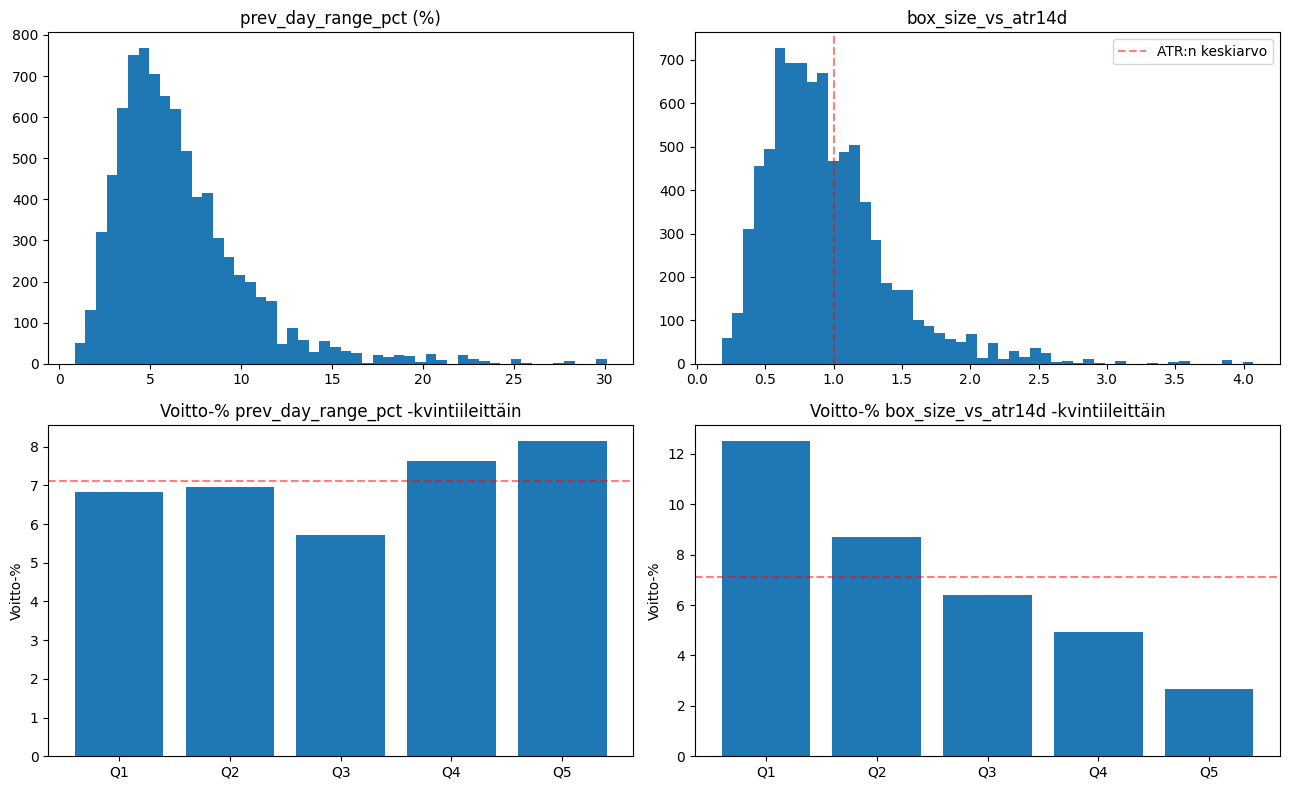


Voitto-% prev_day_range_pct -kvintiileittäin:
                   n  voitto_pct  range_keskiarvo
range_quintile                                   
Q1              1317        6.83             3.01
Q2              1310        6.95             4.57
Q3              1314        5.71             5.96
Q4              1313        7.62             7.72
Q5              1312        8.16            12.47

Voitto-% box_size_vs_atr14d -kvintiileittäin:
                 n  voitto_pct  atr_keskiarvo
atr_quintile                                 
Q1            1317       12.53           0.46
Q2            1312        8.69           0.67
Q3            1311        6.41           0.86
Q4            1313        4.95           1.08
Q5            1313        2.67           1.64


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(df["prev_day_range_pct"].dropna(), bins=50)
axes[0, 0].set_title("prev_day_range_pct (%)")

axes[0, 1].hist(df["box_size_vs_atr14d"].dropna(), bins=50)
axes[0, 1].set_title("box_size_vs_atr14d")
axes[0, 1].axvline(1.0, color="red", linestyle="--", alpha=0.5, label="ATR:n keskiarvo")
axes[0, 1].legend()

labeled = df.dropna(subset=["label", "prev_day_range_pct", "box_size_vs_atr14d"]).copy()

labeled["range_quintile"] = pd.qcut(labeled["prev_day_range_pct"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
range_winrate = labeled.groupby("range_quintile", observed=True)["label"].mean() * 100
axes[1, 0].bar(range_winrate.index.astype(str), range_winrate.values)
axes[1, 0].set_title("Voitto-% prev_day_range_pct -kvintiileittäin")
axes[1, 0].set_ylabel("Voitto-%")
axes[1, 0].axhline(7.1, color="red", linestyle="--", alpha=0.5)

labeled["atr_quintile"] = pd.qcut(labeled["box_size_vs_atr14d"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
atr_winrate = labeled.groupby("atr_quintile", observed=True)["label"].mean() * 100
axes[1, 1].bar(atr_winrate.index.astype(str), atr_winrate.values)
axes[1, 1].set_title("Voitto-% box_size_vs_atr14d -kvintiileittäin")
axes[1, 1].set_ylabel("Voitto-%")
axes[1, 1].axhline(7.1, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("\nVoitto-% prev_day_range_pct -kvintiileittäin:")
print(labeled.groupby("range_quintile", observed=True).agg(
    n=("label", "count"),
    voitto_pct=("label", lambda x: x.mean() * 100),
    range_keskiarvo=("prev_day_range_pct", "mean")
).round(2))

print("\nVoitto-% box_size_vs_atr14d -kvintiileittäin:")
print(labeled.groupby("atr_quintile", observed=True).agg(
    n=("label", "count"),
    voitto_pct=("label", lambda x: x.mean() * 100),
    atr_keskiarvo=("box_size_vs_atr14d", "mean")
).round(2))

In [ ]:
# Korreloiko box_size_vs_atr14d risk_reward_ratio:n kanssa?
labeled[["box_size_vs_atr14d", "risk_reward_ratio", "box_size_pct"]].corr().round(3)

,box_size_vs_atr14d,risk_reward_ratio,box_size_pct
box_size_vs_atr14d,1.000,0.478,0.811
risk_reward_ratio,0.478,1.000,0.470
box_size_pct,0.811,0.470,1.000


In [ ]:
# Onko box_size_pct yksinään ennustepiirre?
labeled["bsp_quintile"] = pd.qcut(labeled["box_size_pct"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])

print("Voitto-% box_size_pct -kvintiileittäin:")
print(labeled.groupby("bsp_quintile", observed=True).agg(
    n=("label", "count"),
    voitto_pct=("label", lambda x: x.mean() * 100),
    keskiarvo=("box_size_pct", "mean")
).round(2))

Voitto-% box_size_pct -kvintiileittäin:
                 n  voitto_pct  keskiarvo
bsp_quintile                             
Q1            1314       12.94       2.50
Q2            1313        7.31       3.87
Q3            1313        7.46       5.01
Q4            1313        5.10       6.60
Q5            1313        2.44      10.88
